**PHASE 2. FEATURE ENGINEERING & MODEL VALIDATION**

In the previous phase, we have obtained an AR(1) + GARCH(1,1) + student-t model which was trained purely based on historical return. In this phase, we will aim to use scikit-learn to conduct feature engineering, which involves refining the obtained GARCH model by adding supplementary training references.

**I. Data and resources preparation**

We first fetch the bitcoin data price from Yahoo Finance from 2018. We define two base values of the data: log-difference and GARCH volatility.

1. Log-difference

    This is the data we passed to the ARMA-GARCH model during phase 1. We aim to utilize the log-difference to identify the movement of returns, helping the model to more accurately forecast the conditional volatility of the Bitcoin price.

2. GARCH volatility
    
    This is the conditional volatility (standard deviation which depends on the historic volatility) obtained from ARMA-GARCH model.

In [ ]:
!pip install arch
from arch import arch_model
import yfinance as yf
import numpy as np
btc = yf.download("BTC-USD", start="2018-01-01", interval="1d")
btc = btc[['Close']]
btc.dropna(inplace=True)
log_diff = np.log(btc['Close']).diff()
log_diff.dropna(inplace=True)
res = arch_model(log_diff * 10, vol = "GARCH", mean = "ARX", lags = 1, p = 1, q = 1, dist = 't').fit(disp = 'off') #Multiplication by 10 due to recommended scaling
btc = btc.iloc[1:].copy()  #align with log_diff
btc['log_return'] = log_diff.values
btc['garch_volatility'] = res.conditional_volatility / 10 #Division by 10 to calibrate the scaling

**II. Methodologies**

Features are defined as supplementary informations for the model to obtain more-accurate result by taking account different factors (not only past data). We define several features for the model:

1. Lag return (*return_lag_1, return_lag_2* )

    Lag return is defined as the return on some data point in the past. This will give the model a sense of how return in the past influences current return, which is consistent to identifying autocorrelation within returns.

2. Lag volatility (*garch_vol_lag_1, garch_vol_lag_2, target_volatility* )

    Our goal is to predict the price volatility by capturing the volatility clustering. Similar to lag return, this gives information about the movement of volatility (volatility cluster). This is the primary driver of our model, as we will train our model based on current and previous volatility relationship.

3. Rolling mean (*rolling_mean_7* )

    Rolling mean will give a sense to the model of "*what is happening to the return recently*"; or in other word, it provides contexts about the trend of price return.

In [2]:
btc['return_lag_1'] = btc['log_return'].shift(1) #Yesterday's return
btc['return_lag_2'] = btc['log_return'].shift(2) #Return two days ago
btc['garch_vol_lag_1'] = btc['garch_volatility'].shift(1) #Yesterday's volatility
btc['garch_vol_lag_2'] = btc['garch_volatility'].shift(2) #Volatility two days ago
btc['rolling_mean_7'] = btc['log_return'].rolling(7).mean() #Weekly rolling mean
btc['target_volatility'] = btc['garch_volatility'].shift(-1) #What is tomorrow's volatility, given current volatility. This is what we are interested to forecast
features = [
    'return_lag_1',
    'return_lag_2',
    'garch_vol_lag_1',
    'garch_vol_lag_2',
    'rolling_mean_7'
]
btc = btc.dropna().copy()

As we are trying to train the model, we may use a train-test split. Like before, we use 80% of the data to train, and the rest 20% to test the data.

In [3]:
train_size = int(len(btc) * 0.8)
train = btc.iloc[:train_size]
test = btc.iloc[train_size:]
X_train = train[features]
y_train = train['target_volatility']
X_test = test[features]
y_test = test['target_volatility']

In [4]:
#Setting up the training resources (using scikit-learn)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler())
])

X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test) #We do not re-fit the actual data in the test portion to prevent data leakage from the actual test data.

Since the return data is not linear, we will use Random Forest Regressor. Random Forest Regressor involves large number of randomly generated decision trees, which also consider several factors (features) in the forecasting process.

In [5]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 100, max_depth = 5, random_state = 123)
model.fit(X_train_scaled, y_train) #Data training
y_pred = model.predict(X_test_scaled) #Prediction result

To accurately assess the usefulness of our training model, we could compare with two baseline models:
1. Mean model: This is the simplest model which serves as a preliminary baseline of our forecasting model, which always takes a constant value, mean of past volatilities.

2. Persistence model: The clustered volatility establishes the pattern where the volatility on the next day will reflect the volatility today, and the volatility today will be reflected by the volatility yesterday. This model compares current actual volatility and yesterday's actual volatility, making this baseline particularly difficult to be beaten, since the volatility clustering behaviour.

We assess the performances of both model (baseline models and our prediction model) based on RMSE (Root Mean Square Error) and MAE (Mean Absolute Error). We aim our model to achieve both metrics less than the baseline model, otherwise the model is not very useful.

In [6]:
#Mean model comparison
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
training_vol_mean = np.mean(y_train)
training_vol_mean = pd.Series([training_vol_mean] * len(y_test))
mean_rmse = np.sqrt(mean_squared_error(y_test, training_vol_mean))
model_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mean_mae = mean_absolute_error(y_test, training_vol_mean)
model_mae = mean_absolute_error(y_test, y_pred)
print(f"Mean RMSE: {mean_rmse}")
print(f"Model RMSE: {model_rmse}")
print(f"Mean MAE: {mean_mae}")
print(f"Model MAE: {model_mae}")

Mean RMSE: 0.011321686910735545
Model RMSE: 0.0021065954302345383
Mean MAE: 0.01032038972040874
Model MAE: 0.001357930335339856


Both RMSE and MAE of our model beats the mean baseline model, making our model passes the preliminary test. Now we compare with the persistence model.

In [7]:
#Persistence model comparison
baseline_pred = test['garch_vol_lag_1'].dropna()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Model RMSE:", rmse)
print("Baseline RMSE:", baseline_rmse)
print("Model MAE:", mae)
print("Baseline MAE:", baseline_mae)

Model RMSE: 0.0021065954302345383
Baseline RMSE: 0.0023196145928963932
Model MAE: 0.001357930335339856
Baseline MAE: 0.0012939929360082615


It is visible that our model has better RMSE, but slightly worse MAE (as of July 9th, 2026). Since RMSE spikes during large error, the result suggests that our model outperforms when handling large spikes, which is desirable in crypto market as the majority will anticipate large volatility. However, our model is not sufficiently capable of handling low-volatility periods (as shown in the figure below). Since MAE weighs equally for large and small errors, this results in higher MAE, suggesting that improvement is required for our model.

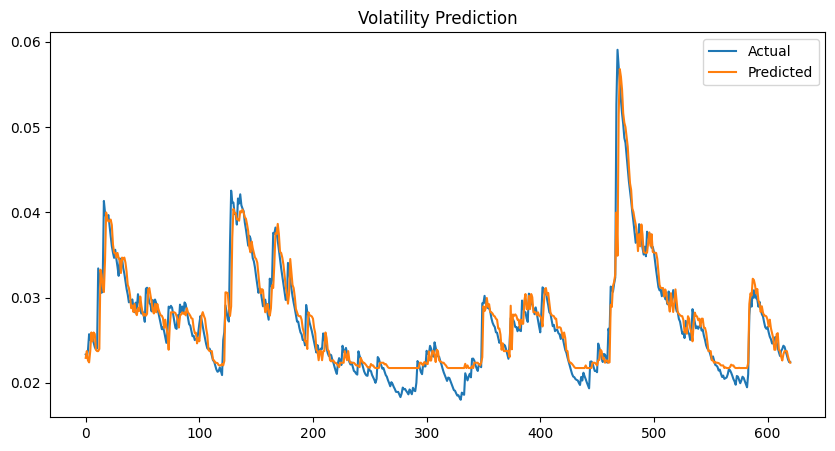

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Volatility Prediction")
plt.show()

Below are the feature importances

In [11]:
importances = pd.Series(model.feature_importances_, index = features)
print(importances.sort_values(ascending=False))
#--> Effects from lag 1 GARCH volatility dominates the prediction model

garch_vol_lag_1    0.923879
rolling_mean_7     0.056222
return_lag_1       0.011096
garch_vol_lag_2    0.008566
return_lag_2       0.000237
dtype: float64


We first analyze why our model fails to capture low-volatility periods. Recall the features used to train the model: lag return, lag volatility (from GARCH), and rolling mean. The only proxy which has direct relevancy for model training is lag volatility. Since the lag volatility is modelled from GARCH, which is inherently reactive to high-volatility spikes, and persistent to low-volatility spikes, the model will assume persistent volatility despite rapid volatility drops.

One possible method to improve the performance of our model is to add more feature: rolling volatility. This will provide the model a context of an emerging trend of actual volatility, not just relying on GARCH-based volatility.

In [12]:
#Adding features
btc['rolling_std_3'] = btc['log_return'].rolling(3).std()
btc['rolling_std_7'] = btc['log_return'].rolling(7).std()
btc['rolling_std_14'] = btc['log_return'].rolling(14).std()
features = [
    'return_lag_1',
    'return_lag_2',
    'garch_vol_lag_1',
    'garch_vol_lag_2',
    'rolling_mean_7',
    'rolling_std_3',
    'rolling_std_7',
    'rolling_std_14'
]
btc = btc.dropna().copy()

#Splitting our data (train-test split)
split = int(len(btc) * 0.8)
train = btc.iloc[:split]
test = btc.iloc[split:]

X_train = train[features]
y_train = train['target_volatility']
X_test = test[features]
y_test = test['target_volatility']
baseline_pred = test['garch_vol_lag_1'].dropna()

#Readjust the input data
X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

#Data training and prediction
model = RandomForestRegressor(n_estimators = 100, max_depth = 5, random_state = 123)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [13]:
training_vol_mean = np.mean(y_train)
training_vol_mean = pd.Series([training_vol_mean] * len(y_test))
mean_rmse = np.sqrt(mean_squared_error(y_test, training_vol_mean))
model_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mean_mae = mean_absolute_error(y_test, training_vol_mean)
model_mae = mean_absolute_error(y_test, y_pred)
print(f"Mean RMSE: {mean_rmse}")
print(f"Model RMSE: {model_rmse}")
print(f"Mean MAE: {mean_mae}")
print(f"Model MAE: {model_mae}")

Mean RMSE: 0.011166166740265349
Model RMSE: 0.0013294930941363647
Mean MAE: 0.010163982068987025
Model MAE: 0.0009986629974306563


In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Model RMSE:", rmse)
print("Baseline RMSE:", baseline_rmse)
print("Model MAE:", mae)
print("Baseline MAE:", baseline_mae)

Model RMSE: 0.0013294930941363647
Baseline RMSE: 0.0023230631909659607
Model MAE: 0.0009986629974306563
Baseline MAE: 0.0012962051561526498


Our model now achieves lower RMSE and MAE than both mean model and persistence model, seeing that adding features is effective to significantly improve our model performance. We will perform more in-depth analysis on our model.

As shown on the figure below, adding rolling volatility as a feature reduces model persistent on low-volatility periods, although the model still shows some unreactive response during low-volatility periods due to remaining GARCH effects.

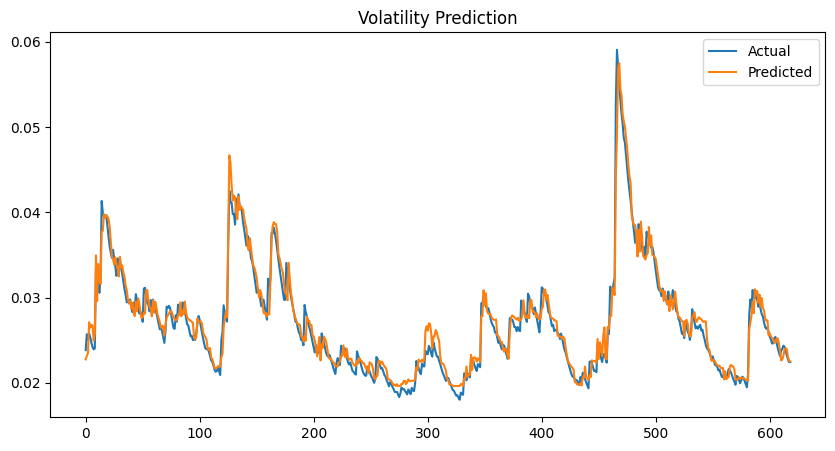

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Volatility Prediction")
plt.show()

Below are the features importance of the new forecasting model.

In [16]:
importances = pd.Series(model.feature_importances_, index = features)
print(importances.sort_values(ascending=False))

garch_vol_lag_1    0.736708
rolling_std_14     0.212479
rolling_std_7      0.017971
rolling_std_3      0.017220
garch_vol_lag_2    0.007961
rolling_mean_7     0.006410
return_lag_1       0.001184
return_lag_2       0.000067
dtype: float64


Now the effect from GARCH volatility is reduced, and rolling_std_14 (bi-weekly rolling volatility) significantly contributes to the model, which fixes the model unreactivity issue during low-volatility periods.

Notwithstanding that, our model is still yet to be perfect. There are some limitations which will be discussed in the next section.

**III. Limitations**



First limitation is the presence of residual autocorrelation, which is shown below.

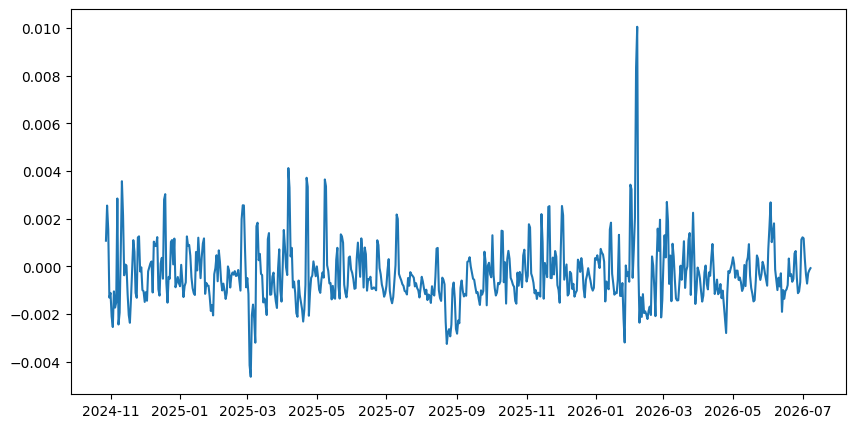

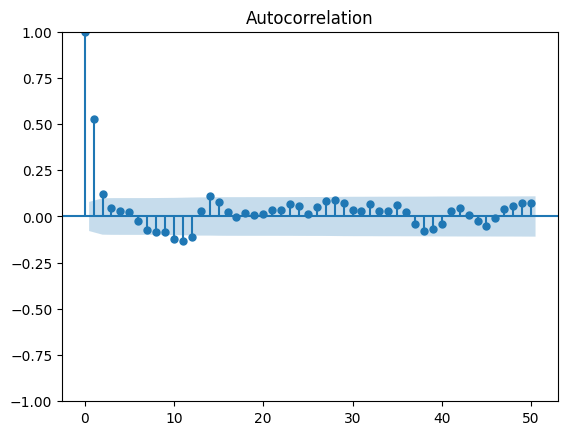

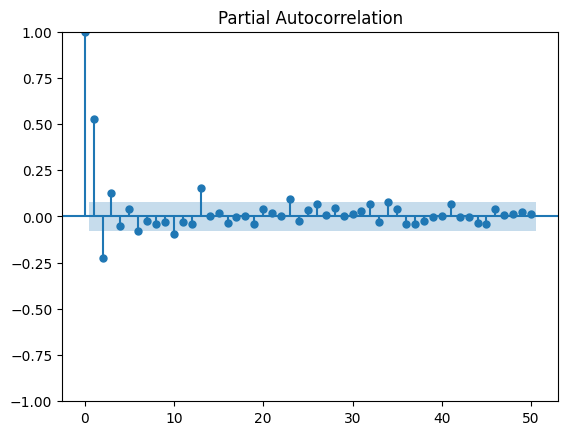

,lb_stat,lb_pvalue
10,207.138001,5.226325e-39
50,293.138999,4.120948e-36


In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

plt.figure(figsize = (10,5))
residual = pd.DataFrame(y_test - y_pred)
plt.plot(residual)
plt.show()

plot_acf(residual, lags = 50)
plt.show()

plot_pacf(residual, lags = 50)
plt.show()

acorr_ljungbox(residual, lags = [10, 50])


The ACF plot (2nd plot) shows a significant pattern from lag 1 onwards, indicating the presence of residual autocorrelation. This assumption is strengthened by a very small Ljung-Box test's p-value, indicating that the residual autocorrelation is very strong.

Despite strong autocorrelation result, our model achieves lower RMSE and MAE of both baseline models (mean model and persistence model), indicating that it captures additional predictive information beyond simple volatility persistence. Therefore, the model remains effective as an volatility forecasting tool.

Another limitation is that our model solely depends on historical market data, and therefore unable to directly incorporate external factors (such as emerging news and fiscal regulation changes). Although the combined external factors reflects the movement of price, and therefore the volatility, our model cannot capture the immediate effects before it is reflected in the market data. This limitation is inherent to the predictive model, rather than the overall system.

Relevant to this, the next phase will integrate natural-language-based explanation layer, which aims to help end-users to understand the underlying context beyond market data movements, aiding the usefulness of the overall system to capture the external factors which our model unable to.